# Airline Passenger Data Analysis Using Python
# Final Project
Developed By: Ali

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [5]:
df=pd.read_csv('airline_passenger_analysis_sample.csv')
df.head()

,Passenger_ID,Passenger_Name,Gender,Age,Country,Flight_Number,Airline,Source,Destination,Travel_Date,Departure_Time,Arrival_Time,Travel_Class,Ticket_Price,Payment_Method,Booking_Channel,Baggage_Weight,Flight_Distance,Flight_Duration,Rating
0,P1001,Passenger_1,Female,31,India,QP129,Akasa Air,Mumbai,Delhi,2025-03-07,03:45,06:40,Business,10237,UPI,Travel Agent,24,1390,175,4.4
1,P1002,Passenger_2,Male,42,UAE,QP843,Air India,Hyderabad,Delhi,2025-03-23,00:00,01:06,First,13142,Card,Mobile App,25,1254,66,3.7
2,P1003,Passenger_3,Male,29,Singapore,AI860,Vistara,Hyderabad,Goa,2025-03-16,00:45,04:07,First,17609,Net Banking,Travel Agent,16,1542,202,3.6
3,P1004,Passenger_4,Female,44,UAE,UK661,Vistara,Goa,Pune,2025-05-31,01:45,03:47,Economy,14685,Net Banking,Travel Agent,26,742,122,4.6
4,P1005,Passenger_5,Female,63,Nepal,6E272,SpiceJet,Jaipur,Pune,2025-04-05,15:00,18:00,Economy,3212,UPI,Website,27,1250,180,3.8


# Data Exploration

In [7]:
print(df.shape)
print(df.info())
df.describe()

(100, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passenger_ID     100 non-null    object 
 1   Passenger_Name   100 non-null    object 
 2   Gender           100 non-null    object 
 3   Age              100 non-null    int64  
 4   Country          100 non-null    object 
 5   Flight_Number    100 non-null    object 
 6   Airline          100 non-null    object 
 7   Source           100 non-null    object 
 8   Destination      100 non-null    object 
 9   Travel_Date      100 non-null    object 
 10  Departure_Time   100 non-null    object 
 11  Arrival_Time     100 non-null    object 
 12  Travel_Class     100 non-null    object 
 13  Ticket_Price     100 non-null    int64  
 14  Payment_Method   100 non-null    object 
 15  Booking_Channel  100 non-null    object 
 16  Baggage_Weight   100 non-null    int64  
 17  Flight_

,Age,Ticket_Price,Baggage_Weight,Flight_Distance,Flight_Duration,Rating
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,41.060000,10629.280000,21.060000,1469.050000,140.87000,3.955000
std,14.373671,4485.503494,6.051663,658.766515,44.73438,0.565931
min,18.000000,2796.000000,10.000000,303.000000,66.00000,3.000000
25%,29.000000,6711.500000,16.000000,974.500000,105.75000,3.500000
50%,40.500000,11083.500000,22.000000,1467.500000,136.00000,4.000000
75%,52.000000,14332.500000,26.000000,2045.000000,175.50000,4.400000
max,65.000000,18000.000000,30.000000,2498.000000,210.00000,4.900000


# Data Cleaning


In [11]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
df['Travel_Date']=pd.to_datetime(df['Travel_Date'])

Passenger_ID       0
Passenger_Name     0
Gender             0
Age                0
Country            0
Flight_Number      0
Airline            0
Source             0
Destination        0
Travel_Date        0
Departure_Time     0
Arrival_Time       0
Travel_Class       0
Ticket_Price       0
Payment_Method     0
Booking_Channel    0
Baggage_Weight     0
Flight_Distance    0
Flight_Duration    0
Rating             0
dtype: int64
0


# Feature Engineering

In [13]:
df['Month']=df['Travel_Date'].dt.month_name()
df['Day']=df['Travel_Date'].dt.day_name()
bins=[17,25,35,45,60,100]
labels=['18-25','26-35','36-45','46-60','60+']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)
df.head()

,Passenger_ID,Passenger_Name,Gender,Age,Country,Flight_Number,Airline,Source,Destination,Travel_Date,...,Ticket_Price,Payment_Method,Booking_Channel,Baggage_Weight,Flight_Distance,Flight_Duration,Rating,Month,Day,Age_Group
0,P1001,Passenger_1,Female,31,India,QP129,Akasa Air,Mumbai,Delhi,2025-03-07,...,10237,UPI,Travel Agent,24,1390,175,4.4,March,Friday,26-35
1,P1002,Passenger_2,Male,42,UAE,QP843,Air India,Hyderabad,Delhi,2025-03-23,...,13142,Card,Mobile App,25,1254,66,3.7,March,Sunday,36-45
2,P1003,Passenger_3,Male,29,Singapore,AI860,Vistara,Hyderabad,Goa,2025-03-16,...,17609,Net Banking,Travel Agent,16,1542,202,3.6,March,Sunday,26-35
3,P1004,Passenger_4,Female,44,UAE,UK661,Vistara,Goa,Pune,2025-05-31,...,14685,Net Banking,Travel Agent,26,742,122,4.6,May,Saturday,36-45
4,P1005,Passenger_5,Female,63,Nepal,6E272,SpiceJet,Jaipur,Pune,2025-04-05,...,3212,UPI,Website,27,1250,180,3.8,April,Saturday,60+


## Business Quesstion
### Total Passengers

In [14]:
len (df)


100

## Total Revenue

In [15]:
df['Ticket_Price'].sum()

1062928

# Average Ticket Price

In [16]:
df['Ticket_Price'].mean()

10629.28

## Passengers By Airline

In [17]:
df['Airline'].value_counts()

Airline
Akasa Air    23
IndiGo       20
Air India    19
Vistara      19
SpiceJet     19
Name: count, dtype: int64

# Revenue By Airline

In [18]:
df.groupby('Airline')['Ticket_Price'].sum()

Airline
Air India    200294
Akasa Air    251866
IndiGo       190958
SpiceJet     207629
Vistara      212181
Name: Ticket_Price, dtype: int64

# Visualizations
# Airline-wise Passengers

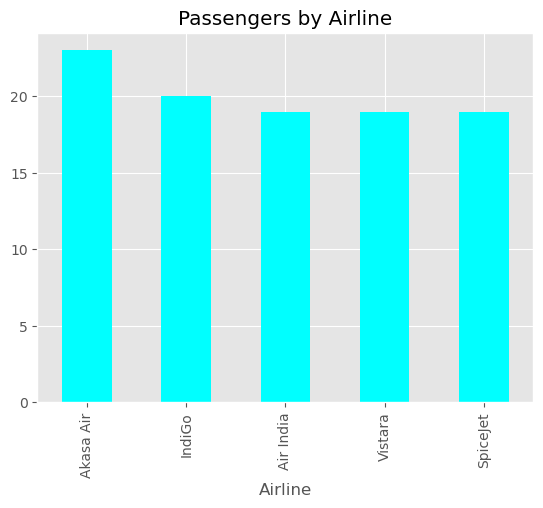

In [21]:
df['Airline'].value_counts().plot(kind='bar',color='cyan')
plt.title('Passengers by Airline')
plt.show()

# Travel Class Distribution

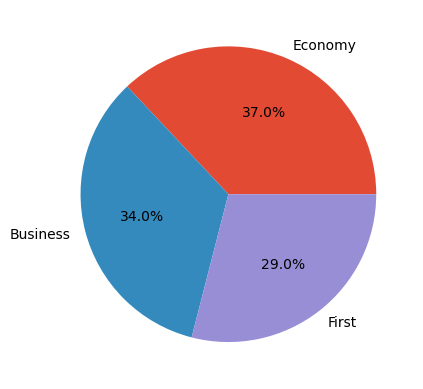

In [24]:
df['Travel_Class'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.show()

# Monthly Bookings


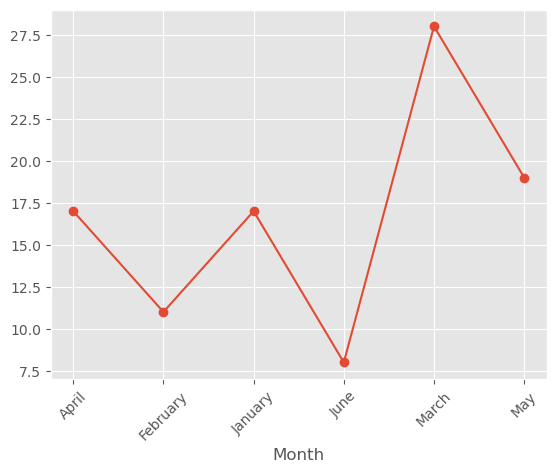

In [26]:
df.groupby('Month').size().plot(kind='line',marker='o')
plt.xticks(rotation=45)
plt.show()

# Ticket Price distribution 1

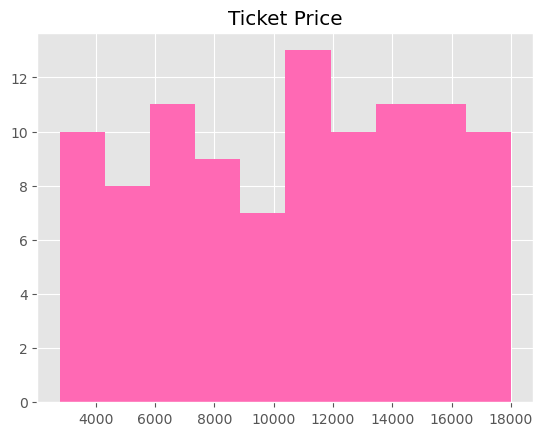

In [30]:
plt.hist(df['Ticket_Price'],bins=10,color='hotpink')
plt.title('Ticket Price')
plt.show()

# Price vs Distance

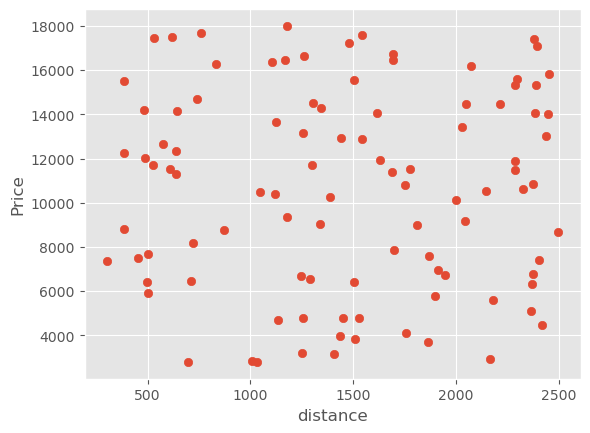

In [34]:
plt.scatter (df['Flight_Distance'],df['Ticket_Price'])
plt.xlabel('distance')
plt.ylabel('Price')
plt.show()

# Business Insights
- Identify top airline.
- Identify peak booking month.
- Compare travel class popularity.
- Recommend marketing strategies.
